# 04.4 - Origin Classification with ModernBERT + Extra Review Text (SCRUBBED)

Identical setup to **04.3** except country names, adjectival forms, and coffee-region aliases are
*scrubbed out* of the concatenated text before training. The scrubbing vocabulary is the authoritative
list from `01_Preprocessing_Scraped_Data.ipynb`.

## Scrubbing policy

Any occurrence of the following is replaced with the placeholder token `[ORIGIN]`:

- Country names and adjectival forms (`ethiopia`, `ethiopian`, `colombia`, `colombian`, ...)
- Coffee-region aliases that uniquely identify a country (`yirgacheffe`, `huehuetenango`, `boquete`, ...)
- Broad geographic region terms (`east africa`, `central america`, ...)

The leakage check cell below verifies the post-scrub leakage rate is near zero.

## What this measures

The comparison **04.4 vs 04.2** tells you how much real extra flavor-to-origin signal the additional
`Notes + Who Should Drink It + Bottom Line` columns carry once the obvious leakage is removed.

The comparison **04.4 vs 04.3** quantifies how much of the 04.3 gain is pure leakage.

## Baselines

- 04.2 ModernBERT on `text_basic_plus_aspects` alone, seed 42: **Macro-F1 = 0.182**
- 04.3 ModernBERT on unscrubbed full concat: see 04.3 results


In [1]:
import os
import re
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, classification_report,
    balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer, DataCollatorWithPadding,
    EarlyStoppingCallback, Trainer, TrainingArguments,
)
from transformers.utils.notebook import NotebookProgressCallback


In [2]:
RANDOM_STATE = 42
MIN_SAMPLES_PER_CLASS = 100
MODEL_CHECKPOINT = 'answerdotai/ModernBERT-base'
TEXT_COLUMN = 'text_full_concat_scrubbed'
MAX_LENGTH = 256

# Best config from 04.2 seed harness
BEST_LR = 3e-5
USE_CLASS_WEIGHTS = False  # plain CE

# Training config (same as 04.2)
NUM_TRAIN_EPOCHS = 12
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
GRAD_ACCUM_STEPS = 2
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.06
EARLY_STOP_PATIENCE = 3
USE_FP16 = True

OUTPUT_DIR_ROOT = 'artifacts/origin_finetuning_modernbert_fulltext_scrubbed'
os.makedirs(OUTPUT_DIR_ROOT, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)


def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(RANDOM_STATE)


Device: cuda


## Build scrubbing vocabulary and regex

In [3]:
# Source of truth for the country/region vocabulary is 01_Preprocessing_Scraped_Data.ipynb
COUNTRY_TERMS = {
    "Ethiopia": ["ethiopia", "ethiopian"],
    "Colombia": ["colombia", "colombian", "columbian"],
    "Panama": ["panama", "panamanian"],
    "Kenya": ["kenya", "kenyan"],
    "Indonesia": ["indonesia", "indonesian"],
    "Guatemala": ["guatemala", "guatemalan"],
    "Costa Rica": ["costa rica", "costa rican", "costarican"],
    "El Salvador": ["el salvador", "salvadoran", "salvadorean", "salvadorian"],
    "Rwanda": ["rwanda", "rwandan"],
    "Brazil": ["brazil", "brazilian"],
    "Honduras": ["honduras", "honduran"],
    "Peru": ["peru", "peruvian"],
    "Taiwan": ["taiwan", "taiwanese"],
    "Papua New Guinea": ["papua new guinea", "papua new guinean"],
    "Nicaragua": ["nicaragua", "nicaraguan"],
    "Burundi": ["burundi", "burundian"],
    "Thailand": ["thailand", "thai"],
    "India": ["india", "indian"],
    "Mexico": ["mexico", "mexican"],
    "Tanzania": ["tanzania", "tanzanian"],
    "Yemen": ["yemen", "yemeni"],
    "Ecuador": ["ecuador", "ecuadorian"],
    "Bolivia": ["bolivia", "bolivian"],
    "Jamaica": ["jamaica", "jamaican"],
    "Uganda": ["uganda", "ugandan"],
    "Dominican Republic": ["dominican republic", "dominican"],
    "Zambia": ["zambia", "zambian"],
    "China": ["china", "chinese"],
    "Vietnam": ["vietnam", "vietnamese"],
    "Philippines": ["philippines", "philippine", "filipino"],
    "Malaysia": ["malaysia", "malaysian"],
    "Laos": ["laos", "laotian"],
    "Zimbabwe": ["zimbabwe", "zimbabwean"],
    "Haiti": ["haiti", "haitian"],
    "Puerto Rico": ["puerto rico", "puerto rican", "puertorican"],
    "Nepal": ["nepal", "nepalese", "nepali"],
    "Myanmar": ["myanmar", "burmese"],
    "Cameroon": ["cameroon", "cameroonian"],
    "Australia": ["australia", "australian"],
    "South Africa": ["south africa", "south african"],
    "Malawi": ["malawi", "malawian"],
    "Venezuela": ["venezuela", "venezuelan", "merida state", "mocoties valley"],
    "Timor-Leste": ["east timor", "timor leste", "timorese"],
    "DR Congo": ["democratic republic of the congo", "dr congo", "congo", "congolese"],
    "United Kingdom": ["united kingdom", "british", "pitcairn island", "saint helena", "st helena", "sandy bay valley"],
    "United States": [
        "usa", "united states", "american",
        "hawaii", "hawai'i", "hawaiian", "hawaii island",
        "big island", "kona", "puna district", "holualoa", "oahu", "maui", "kauai",
        "ka u", "ka'u", "kau",
    ],
}

REGION_ALIASES = {
    "Ethiopia": ["yirgacheffe", "sidamo", "sidama", "guji", "gedeb", "gedeo", "kochere", "hambela",
                 "shakiso", "jimma", "limu", "oromia", "harrar", "kaffa", "bench maji", "bench-maji",
                 "arbegona", "bensa"],
    "Colombia": ["huila", "cauca", "narino", "narino", "tolima", "quindio", "quindio", "caldas",
                 "risaralda", "antioquia", "cundinamarca", "santander", "pitalito", "acevedo",
                 "planadas", "gaitania", "piendamo", "piendamo", "caicedonia", "san agustin", "armenia"],
    "Panama": ["boquete", "chiriqui", "chiriqui", "volcan", "volcan", "jaramillo", "alto quiel",
               "paso ancho", "piedra candela", "canas verdes", "canas verdes", "silla del pando",
               "renacimiento"],
    "Kenya": ["nyeri", "kirinyaga", "kiambu", "embu", "muranga", "murang'a", "thika", "ruiru",
              "mathira", "meru", "nakuru", "gichugu", "karatina"],
    "Indonesia": ["sumatra", "aceh", "gayo", "lintong", "mandheling", "sidikalang", "toraja",
                  "sulawesi", "java", "bali", "kintamani", "flores", "kerinci"],
    "Guatemala": ["huehuetenango", "antigua", "acatenango", "fraijanes", "coban", "atitlan",
                  "atitlan", "chimaltenango", "quiche", "quiche", "solola", "solola", "palencia",
                  "sacatepequez", "sacatepequez", "san marcos", "hoja blanca", "cuilco"],
    "Costa Rica": ["tarrazu", "central valley", "west valley", "tres rios", "tres rios", "naranjo",
                   "dota", "poas", "poas", "alajuela", "brunca", "turrialba", "coto brus",
                   "chirripo", "chirripo"],
    "El Salvador": ["ahuachapan", "ahuachapan", "chalatenango", "apaneca", "ilamatepec", "santa ana",
                    "el boqueron", "el boqueron", "quetzaltepec", "juayua", "juayua", "ataco"],
    "Rwanda": ["gakenke", "nyamasheke", "karongi", "huye", "nyamagabe", "rulindo", "gikongoro",
               "lake kivu"],
    "Brazil": ["cerrado", "mogiana", "minas gerais", "mantiqueira", "sul de minas",
               "chapada diamantina", "carmo de minas"],
    "Honduras": ["marcala", "copan", "copan", "ocotepeque", "comayagua", "intibuca", "intibuca",
                 "santa barbara", "santa barbara", "el paraiso", "el paraiso", "capucas"],
    "Peru": ["cajamarca", "jaen", "jaen", "san ignacio", "chanchamayo", "cusco", "villa rica",
             "oxapampa", "junin", "junin", "puno"],
    "Taiwan": ["alishan", "yunlin", "chiayi", "chia yi", "nantou", "taichung", "pingtung"],
    "Papua New Guinea": ["wahgi valley", "western highlands", "eastern highlands", "jiwaka",
                         "kainantu", "okapa"],
    "Nicaragua": ["jinotega", "matagalpa", "nueva segovia", "madriz", "ocotal", "dipilto"],
    "Burundi": ["kayanza", "ngozi", "muramvya", "muyinga", "bururi"],
    "Thailand": ["chiang rai", "doi chang", "doi pangkhon", "chiang mai", "nan province"],
    "India": ["coorg", "chikmagalur", "karnataka", "bababudangiri", "nilgiris"],
    "Mexico": ["chiapas", "oaxaca", "veracruz", "coatepec", "pluma hidalgo"],
    "Tanzania": ["mbeya", "ruvuma", "ngorongoro", "arusha", "kilimanjaro", "mbozi"],
    "Yemen": ["haraaz", "haraz", "sanaa", "bani matar", "hayma"],
    "Ecuador": ["loja", "pichincha", "imbabura", "zamora", "chimborazo", "saraguro"],
    "Bolivia": ["caranavi", "yungas", "la paz"],
    "Jamaica": ["blue mountain", "blue mountains"],
    "Uganda": ["rwenzori", "bugisu", "sipi falls"],
    "Vietnam": ["lam dong", "quang tri", "dalat", "cau dat"],
    "Philippines": ["benguet", "bukidnon", "davao"],
    "China": ["yunnan", "baoshan", "puer", "pu'er", "lincong"],
    "Puerto Rico": ["utuado", "yauco", "adjuntas"],
    "Venezuela": ["mocoties valley", "merida state"],
    "Malawi": ["malawi"],
}

REGION_ONLY_TERMS = [
    "central america", "south america", "latin america",
    "east africa", "central africa", "west africa", "africa",
    "asia", "the americas", "americas",
    "central and south america", "south and central america",
    "east and central africa", "various africa growing regions",
]

# Flatten all terms into a single list for the regex
all_scrub_terms = []
for v in COUNTRY_TERMS.values():
    all_scrub_terms.extend(v)
for v in REGION_ALIASES.values():
    all_scrub_terms.extend(v)
all_scrub_terms.extend(REGION_ONLY_TERMS)

# Sort longest first so multi-word phrases match before shorter substrings
all_scrub_terms = sorted(set(all_scrub_terms), key=len, reverse=True)
print(f'Loaded {len(all_scrub_terms)} scrub terms')

# Compile one big regex with word boundaries
SCRUB_PATTERN = re.compile(
    r'\b(' + '|'.join(re.escape(t) for t in all_scrub_terms) + r')\b',
    flags=re.IGNORECASE,
)


def scrub(text: str) -> str:
    if not isinstance(text, str) or not text:
        return ''
    return SCRUB_PATTERN.sub(' [ORIGIN] ', text)


Loaded 355 scrub terms


## Load data, concatenate, scrub

In [4]:
df = pd.read_csv('Data/final_coffee_reviews.csv')


def minimal_raw_text(text):
    text = '' if pd.isna(text) else str(text)
    return re.sub(r'\s+', ' ', text).strip().lower()


def normalize_text_keep_brackets(text):
    # lower + collapse whitespace, but keep [ORIGIN] token intact
    text = minimal_raw_text(text)
    text = re.sub(r'[^a-z0-9\s\[\]]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()


EXTRA_TEXT_COLS = ['Blind Assessment', 'Notes', 'Who Should Drink It', 'Bottom Line']


def concat_and_scrub(row):
    pieces = []
    for col in EXTRA_TEXT_COLS:
        v = row[col]
        if pd.notna(v) and str(v).strip():
            # 1. lowercase/whitespace normalize
            raw = minimal_raw_text(v)
            # 2. scrub country/region names
            scrubbed = scrub(raw)
            # 3. normalize remaining text but preserve [ORIGIN]
            cleaned = normalize_text_keep_brackets(scrubbed)
            pieces.append(cleaned)
    return ' '.join(p for p in pieces if p)


df['text_full_concat_scrubbed'] = df.apply(concat_and_scrub, axis=1)
df['text_raw_minimal'] = df['Blind Assessment'].fillna('').map(minimal_raw_text)

df['origin_country'] = df['Country'].astype('string').str.strip()
df['origin_country'] = df['origin_country'].replace('', pd.NA)

work = df[(df['text_raw_minimal'].str.len() >= 30) & (df['origin_country'].notna())].copy()
counts = work['origin_country'].value_counts()
valid_classes = counts[counts >= MIN_SAMPLES_PER_CLASS].index
work = work[work['origin_country'].isin(valid_classes)].copy().reset_index(drop=True)

# IMPORTANT: override TEXT_COLUMN name used in split block
TEXT_COLUMN = 'text_full_concat_scrubbed'
work.rename(columns={'text_full_concat_scrubbed': TEXT_COLUMN}, inplace=False)

print('Rows:', len(work), 'Classes:', work['origin_country'].nunique())
print('Avg scrubbed text length (chars):', int(work[TEXT_COLUMN].str.len().mean()))


Rows: 6820 Classes: 15
Avg scrubbed text length (chars): 874


## Leakage check (post-scrub - should be near zero)

In [5]:
# Leakage check AFTER scrubbing - should be near zero
def contains_own_country(row):
    t = row[TEXT_COLUMN].lower()
    c = str(row['origin_country']).lower()
    return c in t if c and t else False


work['leaks_country'] = work.apply(contains_own_country, axis=1)
leak_rate = float(work['leaks_country'].mean())

print(f'POST-SCRUB LEAKAGE RATE: {leak_rate:.1%} (target: <2%)')
print()

# Show any remaining leaks for inspection
residual = work[work['leaks_country']]
if len(residual) > 0:
    print(f'{len(residual)} samples still leak. First 5:')
    for _, r in residual.head(5).iterrows():
        print(f"[{r['origin_country']}]  ...{r[TEXT_COLUMN][-300:]}")
        print()
else:
    print('No residual leaks detected.')

print()
print('--- 3 scrubbed samples (first 500 chars) ---')
for i in range(3):
    row = work.iloc[i]
    preview = row[TEXT_COLUMN][:500]
    print(f"[{row['origin_country']}]  {preview}...")
    print()


POST-SCRUB LEAKAGE RATE: 0.8% (target: <2%)

52 samples still leak. First 5:
[Colombia]  ...y an effort by procter and gamble to inject a branch of the venerable folgers brand into the whole bean specialty world call 800 275 1967 for more info some folgers 100 colombias i have sampled were decent coffees in the traditional [origin] breakfast mode but i wouldn t recommend this bag to anyone

[Colombia]  ...olgers is a 160 year old coffee brand founded in san francisco acquired in 1963 by procter gamble and sold in 2008 to the j m smucker company visit www folgers com or call 800 937 9745 for more information a particularly bad dark roasted [origin] at the tail end of a bad year for colombias generally

[Honduras]  ...sted by a family owned business the [origin] coffee company this subtle blend of roasts is named for the family patriarch anastacio who recently retired from farming at an age of over 80 visit www hondurascoffeecompany com or call 877 466 3872 for more info those who prefer

## Stratified 70/15/15 split (same RANDOM_STATE as 04.2 and 04.3)

In [6]:
y = work['origin_country']
row_idx = work.index

train_idx, temp_idx, y_train, y_temp = train_test_split(
    row_idx, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
val_idx, test_idx, y_val, y_test = train_test_split(
    temp_idx, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print('Train/Val/Test:', len(train_idx), len(val_idx), len(test_idx))

label_names = sorted(work['origin_country'].unique())
label2id = {label: idx for idx, label in enumerate(label_names)}
id2label = {idx: label for label, idx in label2id.items()}

train_texts = work.loc[train_idx, TEXT_COLUMN].fillna('').tolist()
val_texts   = work.loc[val_idx,   TEXT_COLUMN].fillna('').tolist()
test_texts  = work.loc[test_idx,  TEXT_COLUMN].fillna('').tolist()

train_labels = work.loc[train_idx, 'origin_country'].map(label2id).tolist()
val_labels   = work.loc[val_idx,   'origin_country'].map(label2id).tolist()
test_labels  = work.loc[test_idx,  'origin_country'].map(label2id).tolist()

class_weights_np = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(label_names)),
    y=np.array(train_labels),
)
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float)


Train/Val/Test: 4774 1023 1023


## Tokenize and build datasets

In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


class CoffeeOriginDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.encodings = tokenizer(texts, truncation=True, max_length=max_length, padding=False)
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


train_dataset = CoffeeOriginDataset(train_texts, train_labels, tokenizer, MAX_LENGTH)
val_dataset   = CoffeeOriginDataset(val_texts,   val_labels,   tokenizer, MAX_LENGTH)
test_dataset  = CoffeeOriginDataset(test_texts,  test_labels,  tokenizer, MAX_LENGTH)
print('Datasets ready.')
print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}')


Datasets ready.
Train: 4774, Val: 1023, Test: 1023


## Metrics, Trainer, and run_one (copied from 04.2)

In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='macro', zero_division=0
    )
    return {
        'accuracy': accuracy_score(labels, preds),
        'balanced_accuracy': balanced_accuracy_score(labels, preds),
        'precision_macro': precision,
        'recall_macro': recall,
        'f1_macro': f1,
    }


class WeightedTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop('labels')
        outputs = model(**inputs)
        logits = outputs.get('logits')
        loss_fct = torch.nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss


def build_training_args(output_dir: str, learning_rate: float):
    return TrainingArguments(
        output_dir=output_dir,
        learning_rate=learning_rate,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM_STEPS,
        num_train_epochs=NUM_TRAIN_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        warmup_ratio=WARMUP_RATIO,
        eval_strategy='epoch',
        save_strategy='epoch',
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        greater_is_better=True,
        logging_strategy='epoch',
        disable_tqdm=True,
        report_to='none',
        fp16=USE_FP16 and torch.cuda.is_available(),
        seed=RANDOM_STATE,
    )


def run_one(learning_rate: float, use_class_weights: bool, tag: str):
    set_seed(RANDOM_STATE)
    out_dir = os.path.join(OUTPUT_DIR_ROOT, tag)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_CHECKPOINT,
        num_labels=len(label_names),
        id2label=id2label,
        label2id=label2id,
    )
    args = build_training_args(out_dir, learning_rate)
    trainer_cls = WeightedTrainer if use_class_weights else Trainer
    extra = dict(class_weights=class_weights_tensor) if use_class_weights else {}
    trainer = trainer_cls(
        model=model, args=args,
        train_dataset=train_dataset, eval_dataset=val_dataset,
        processing_class=tokenizer, data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOP_PATIENCE)],
        **extra,
    )
    try:
        trainer.remove_callback(NotebookProgressCallback)
    except Exception:
        pass
    print(f"\n=== Training {tag} | lr={learning_rate} | weighted={use_class_weights} ===")
    train_out = trainer.train()
    val_metrics = trainer.evaluate(eval_dataset=val_dataset)
    test_metrics = trainer.evaluate(eval_dataset=test_dataset, metric_key_prefix='test')
    return trainer, train_out, val_metrics, test_metrics


## Train with best config from 04.2 seed harness

Expected runtime: ~4 minutes.

In [9]:
tag = f'scrubbed_lr{BEST_LR:.0e}_seed{RANDOM_STATE}'
trainer_trained, train_out, val_m, test_m = run_one(
    BEST_LR, use_class_weights=USE_CLASS_WEIGHTS, tag=tag
)

headline = {
    'tag': tag,
    'lr': BEST_LR,
    'weighted': USE_CLASS_WEIGHTS,
    'seed': RANDOM_STATE,
    'val_f1_macro': val_m['eval_f1_macro'],
    'val_balanced_accuracy': val_m['eval_balanced_accuracy'],
    'val_accuracy': val_m['eval_accuracy'],
    'test_f1_macro': test_m['test_f1_macro'],
    'test_balanced_accuracy': test_m['test_balanced_accuracy'],
    'test_accuracy': test_m['test_accuracy'],
    'post_scrub_leakage_rate': leak_rate,
}
print()
print(json.dumps(headline, indent=2))


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': None, 'bos_token_id': None}.



=== Training scrubbed_lr3e-05_seed42 | lr=3e-05 | weighted=False ===
{'loss': '4.321', 'grad_norm': '24.39', 'learning_rate': '2.934e-05', 'epoch': '1'}
{'eval_loss': '1.707', 'eval_accuracy': '0.4858', 'eval_balanced_accuracy': '0.218', 'eval_precision_macro': '0.3255', 'eval_recall_macro': '0.218', 'eval_f1_macro': '0.2009', 'eval_runtime': '7.868', 'eval_samples_per_second': '130', 'eval_steps_per_second': '4.067', 'epoch': '1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '2.644', 'grad_norm': '44.01', 'learning_rate': '2.67e-05', 'epoch': '2'}
{'eval_loss': '1.185', 'eval_accuracy': '0.6295', 'eval_balanced_accuracy': '0.4185', 'eval_precision_macro': '0.577', 'eval_recall_macro': '0.4185', 'eval_f1_macro': '0.4382', 'eval_runtime': '9.57', 'eval_samples_per_second': '106.9', 'eval_steps_per_second': '3.344', 'epoch': '2'}


...

{'loss': '0.0001587', 'grad_norm': '0.03634', 'learning_rate': '2.784e-06', 'epoch': '11'}
{'eval_loss': '1.348', 'eval_accuracy': '0.7419', 'eval_balanced_accuracy': '0.598', 'eval_precision_macro': '0.6705', 'eval_recall_macro': '0.598', 'eval_f1_macro': '0.622', 'eval_runtime': '3.126', 'eval_samples_per_second': '327.3', 'eval_steps_per_second': '10.24', 'epoch': '11'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '1380', 'train_samples_per_second': '41.5', 'train_steps_per_second': '1.304', 'train_loss': '0.8578', 'epoch': '11'}
{'eval_loss': '1.27', 'eval_accuracy': '0.7468', 'eval_balanced_accuracy': '0.6095', 'eval_precision_macro': '0.6554', 'eval_recall_macro': '0.6095', 'eval_f1_macro': '0.6269', 'eval_runtime': '3.471', 'eval_samples_per_second': '294.7', 'eval_steps_per_second': '9.219', 'epoch': '11'}


early stopping required metric_for_best_model, but did not find eval_f1_macro so early stopping is disabled


{'test_loss': '1.159', 'test_accuracy': '0.7556', 'test_balanced_accuracy': '0.653', 'test_precision_macro': '0.7058', 'test_recall_macro': '0.653', 'test_f1_macro': '0.6691', 'test_runtime': '3.112', 'test_samples_per_second': '328.7', 'test_steps_per_second': '10.28', 'epoch': '11'}

{
  "tag": "scrubbed_lr3e-05_seed42",
  "lr": 3e-05,
  "weighted": false,
  "seed": 42,
  "val_f1_macro": 0.6269469388925041,
  "val_balanced_accuracy": 0.6095277693747841,
  "val_accuracy": 0.7468230694037146,
  "test_f1_macro": 0.6691464055141229,
  "test_balanced_accuracy": 0.6530418064969175,
  "test_accuracy": 0.7556207233626588,
  "post_scrub_leakage_rate": 0.007624633431085044
}


## Per-class report and confusion matrix

== Test headline ==
Macro-F1:          0.6691
Balanced Accuracy: 0.6530
Accuracy:          0.7556

Test per-class report:
               precision    recall  f1-score   support

     Ethiopia      0.867     0.853     0.860       299
     Colombia      0.643     0.791     0.709       148
        Kenya      0.936     0.838     0.884       105
    Guatemala      0.634     0.702     0.667        84
    Indonesia      0.730     0.676     0.702        68
   Costa Rica      0.688     0.589     0.635        56
       Panama      0.774     0.906     0.835        53
United States      0.878     0.800     0.837        45
  El Salvador      0.524     0.611     0.564        36
       Brazil      0.680     0.567     0.618        30
       Rwanda      0.800     0.889     0.842        27
         Peru      0.600     0.300     0.400        20
    Nicaragua      0.529     0.474     0.500        19
     Honduras      0.429     0.333     0.375        18
       Mexico      0.875     0.467     0.609        

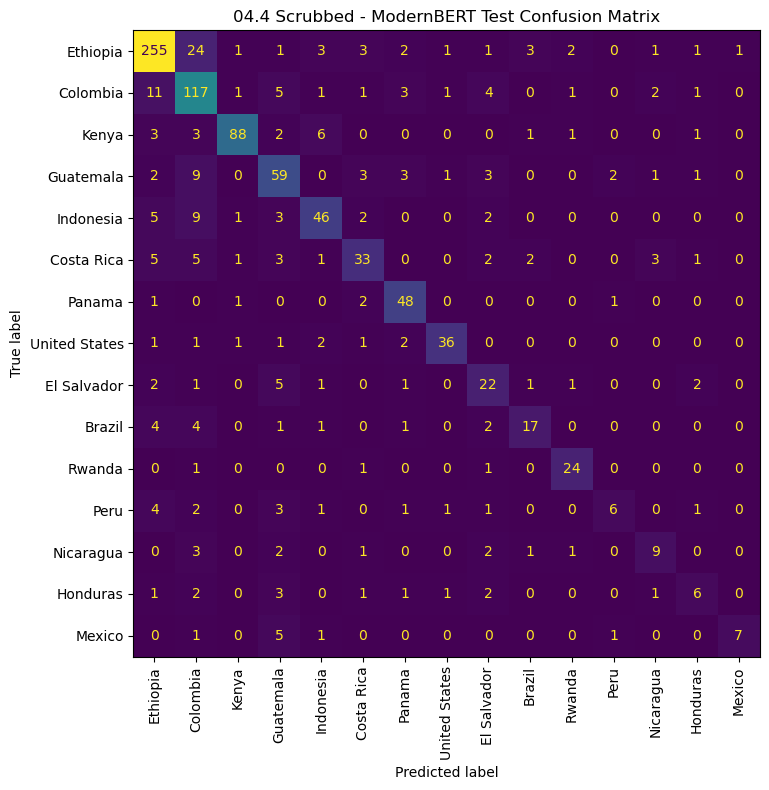

In [10]:
test_pred_output = trainer_trained.predict(test_dataset)
test_pred_ids = np.argmax(test_pred_output.predictions, axis=1)
test_true_labels = [id2label[i] for i in test_labels]
test_pred_labels = [id2label[i] for i in test_pred_ids]

print('== Test headline ==')
print(f"Macro-F1:          {f1_score(test_true_labels, test_pred_labels, average='macro', zero_division=0):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(test_true_labels, test_pred_labels):.4f}")
print(f"Accuracy:          {accuracy_score(test_true_labels, test_pred_labels):.4f}")

class_order = work['origin_country'].value_counts().index.tolist()
print()
print('Test per-class report:')
print(classification_report(test_true_labels, test_pred_labels, labels=class_order, zero_division=0, digits=3))

cm = confusion_matrix(test_true_labels, test_pred_labels, labels=class_order)
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_order).plot(
    ax=ax, xticks_rotation=90, colorbar=False,
)
plt.title('04.4 Scrubbed - ModernBERT Test Confusion Matrix')
plt.tight_layout()
plt.show()


## Save results

In [11]:
with open(os.path.join(OUTPUT_DIR_ROOT, 'results.json'), 'w') as f:
    json.dump({
        'notebook': '04.4_Origin_Classification_ModernBERT_FullText_Scrubbed',
        'model': MODEL_CHECKPOINT,
        'text_columns_used': EXTRA_TEXT_COLS,
        'scrubbed': True,
        'num_scrub_terms': len(all_scrub_terms),
        'post_scrub_leakage_rate': leak_rate,
        'config': {
            'lr': BEST_LR, 'weighted': USE_CLASS_WEIGHTS,
            'epochs': NUM_TRAIN_EPOCHS, 'early_stop_patience': EARLY_STOP_PATIENCE,
            'seed': RANDOM_STATE, 'max_length': MAX_LENGTH,
        },
        'headline': headline,
        'baselines': {
            'modernbert_04_2_blind_assessment_only_seed42': 0.1823,
        },
    }, f, indent=2)
print('Saved', os.path.join(OUTPUT_DIR_ROOT, 'results.json'))


Saved artifacts/origin_finetuning_modernbert_fulltext_scrubbed\results.json


## Interpretation

Compare to the two references:

| Result | Macro-F1 | Interpretation |
|---|---|---|
| 04.2 (Blind Assessment only) | 0.182 | Clean flavor-to-origin baseline |
| 04.3 (unscrubbed full concat) | ? | Upper bound with leakage |
| **04.4 (scrubbed full concat)** | **?** | Clean version of extra-text experiment |

- **04.4 F1 > 0.182**: the extra columns carry genuine flavor/context signal beyond Blind Assessment.
  Keep this as an improvement over 04.2.
- **04.4 F1 ~ 0.182**: extra columns add no meaningful signal once leakage is removed. The 04.3
  improvement was essentially all leakage.
- **04.4 F1 < 0.182**: extra columns add *noise* (probably because `Notes` often discusses roasting,
  marketing, donations rather than flavor). Revert to Blind-Assessment-only.

Either way, this is a clean thesis-quality ablation that answers the question honestly.